In [1]:
%load_ext autoreload
%autoreload 2

from qs_mps.mps_class import MPS
from qs_mps.utils import tensor_shapes, create_sequential_colors, von_neumann_entropy
import numpy as np

import matplotlib.pyplot as plt

# default parameters of the plot layout
plt.rcParams["text.usetex"] = True  # use latex
plt.rcParams["font.size"] = 13
plt.rcParams["figure.dpi"] = 300
plt.rcParams["figure.constrained_layout.use"] = True

In [ ]:
def get_gs(kwargs):
    mps_chain = MPS(L=kwargs.get("L"),
                            d=kwargs.get("d"),
                            model=kwargs.get("model"),
                            chi=kwargs.get("chi"),
                            J=kwargs.get("Jz"),
                            h=kwargs.get("J_perp"),
                            k=(kwargs.get("t"),kwargs.get("tp")) ,
                            eps=kwargs.get("eps")) 
    mps_chain.load_sites(path=kwargs.get("path"), precision=kwargs.get("precision"))
    return mps_chain

In [ ]:
Ls = [3,5,7,9,11,13,15,17]
chis = [150,200,250]
path = "D:work/projects/6_TJ"
for l in Ls:
    for chi in chis:
        args = dict(L=l, d=3, model="tj", chi=chi, Jz=10, J_perp=2, t=2, tp=2, eps=0, path=path, precision=3)
        mps_chain = get_gs(args)
        mps_chain.canonical_form()
        print(von_neumann_entropy(mps_chain.bonds[l//2]))

In [ ]:
loc_mag = []
for i in range(1,mps_chain.L+1):
    mps_chain.local_param(site=i, op="Z")
    loc_mag.append(mps_chain.mpo_first_moment().real)
locs = [(i, loc) for i, loc in enumerate(loc_mag)]

In [ ]:
locs[(l//2-1):(l//2+3)]

In [ ]:
L = 48
mps_expanded = MPS(L=L, d=3, model="tj", chi=chi, J=10, h=2, k=(2,2), eps=0)
block_mps = MPS(L=4, d=3, model="tj", chi=chi, J=10, h=2, k=(2,2), eps=0)

block_mps.sites = mps_chain.sites[(l//2-1):(l//2+3)].copy()
# tensor_shapes(block_mps.sites)

mps_expanded.sites = block_mps.sites * (L//4)
mps_chain.enlarge_chi(noise_std=1e-7)
mps_expanded.sites = mps_chain.sites[0] + mps_expanded.sites + mps_chain.sites[-1]
mps_expanded.L = len(mps_expanded.sites)
tensor_shapes(mps_expanded.sites)
mps_expanded.canonical_form()

print(mps_expanded._compute_norm())

loc_mag = []
for i in range(1,mps_expanded.L+1):
    mps_expanded.local_param(site=i, op="Z")
    loc_mag.append(mps_expanded.mpo_first_moment().real)
loc_mag

In [97]:
from qs_mps.mps_class import MPS
L=20
d = 3
Jz = 10
J_perp = 1
t = 1
tp = 1
model = "tj"
chis = [20,40,60,80]
eps = 1e-2
path = "D:/work/projects/6_TJ"
hole_tn = np.array([[[0],[1],[0]]])
up_tn = np.array([[[1],[0],[0]]])
down_tn = np.array([[[0],[0],[1]]])
number_of_holes = 3
rng = np.random.default_rng()
defect_sites = rng.choice(L, size=number_of_holes, replace=False)
defect_sites = [L//2-1, L//2]
print(defect_sites)
precision = 3
hole_occup = []
spin_occup = []
for chi in chis:
    mps_chain = MPS(L=L,d=d,model=model,chi=chi,J=Jz,h=J_perp,k=(t,tp),eps=eps)
    mps_chain._random_state(301)
    for i in range(L):
        if (i % 2) == 0:
            mps_chain.sites[i] = up_tn.copy()
        elif (i % 2) == 1:
            mps_chain.sites[i] = down_tn.copy()
    mps_chain.enlarge_chi(noise_std=1e-6)
    mps_chain.canonical_form()
    # for i in range(L):
    #     mps_chain.sites[i] = hole_tn.copy()
    # mps_chain.enlarge_chi(noise_std=1e-6)
    # mps_chain.canonical_form()
    # # tensor_shapes(mps_chain.sites)
    # print("------------before----------------")
    # mps_chain.order_param(op="nh")
    # print(mps_chain.mpo_first_moment())
    # mps_chain.w = None
    mps_chain.DMRG(trunc_tol=False, trunc_chi=True, n_sweep=10, defect=True, defect_sites=defect_sites)
    hole_occup_chi = []
    for i in range(1,mps_chain.L+1):
        mps_chain.local_param(site=i, op="nh")
        hole_occup_chi.append(mps_chain.mpo_first_moment().real)
    spin_occup_chi = []
    for i in range(1,mps_chain.L+1):
        mps_chain.local_param(site=i, op="Z")
        spin_occup_chi.append(mps_chain.mpo_first_moment().real)
    print("------------after----------------")
    mps_chain.order_param(op="nh")
    print("holes", mps_chain.mpo_first_moment())
    mps_chain.order_param(op="Z")
    print("mag", mps_chain.mpo_first_moment())
    hole_occup.append(hole_occup_chi)
    spin_occup.append(spin_occup_chi)

[9, 10]


C:\Users\HP\Desktop\qs-mps\src\qs_mps\mps_class.py:14: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  from qs_mps.utils import *
C:\Users\HP\Desktop\qs-mps\src\qs_mps\mps_class.py:1958: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  self.w = w_tot
C:\Users\HP\Desktop\qs-mps\src\qs_mps\mps_class.py:1956: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the 

------------after----------------
holes (2.003289352828729+9.730739644122567e-17j)
mag (-0.0032987286603431277+2.248275836349683e-17j)


C:\Users\HP\Desktop\qs-mps\src\qs_mps\mps_class.py:18: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  sparse_ising_ground_state,
C:\Users\HP\Desktop\qs-mps\src\qs_mps\mps_class.py:16: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  from qs_mps.sparse_hamiltonians_and_operators import (


------------after----------------
holes (2.0032890651668667+2.208627080952564e-16j)
mag (-0.003298684769370206-1.1516035265223479e-18j)
------------after----------------
holes (2.003288877208915+7.697711282931713e-18j)
mag (-0.003590146813317598+1.3851239873569215e-16j)
------------after----------------
holes (2.002821958166772-1.0262536707136326e-16j)
mag (-0.7312564841159158-1.1738295079613401e-16j)


<>:4: SyntaxWarning: "\c" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\c"? A raw string is also an option.
<>:4: SyntaxWarning: "\c" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\c"? A raw string is also an option.


C:\Users\HP\AppData\Local\Temp\ipykernel_34696\71960941.py:4: SyntaxWarning: "\c" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\c"? A raw string is also an option.
  plt.plot(occup, color=colors[i], label=f"$\chi={chis[i]}$")


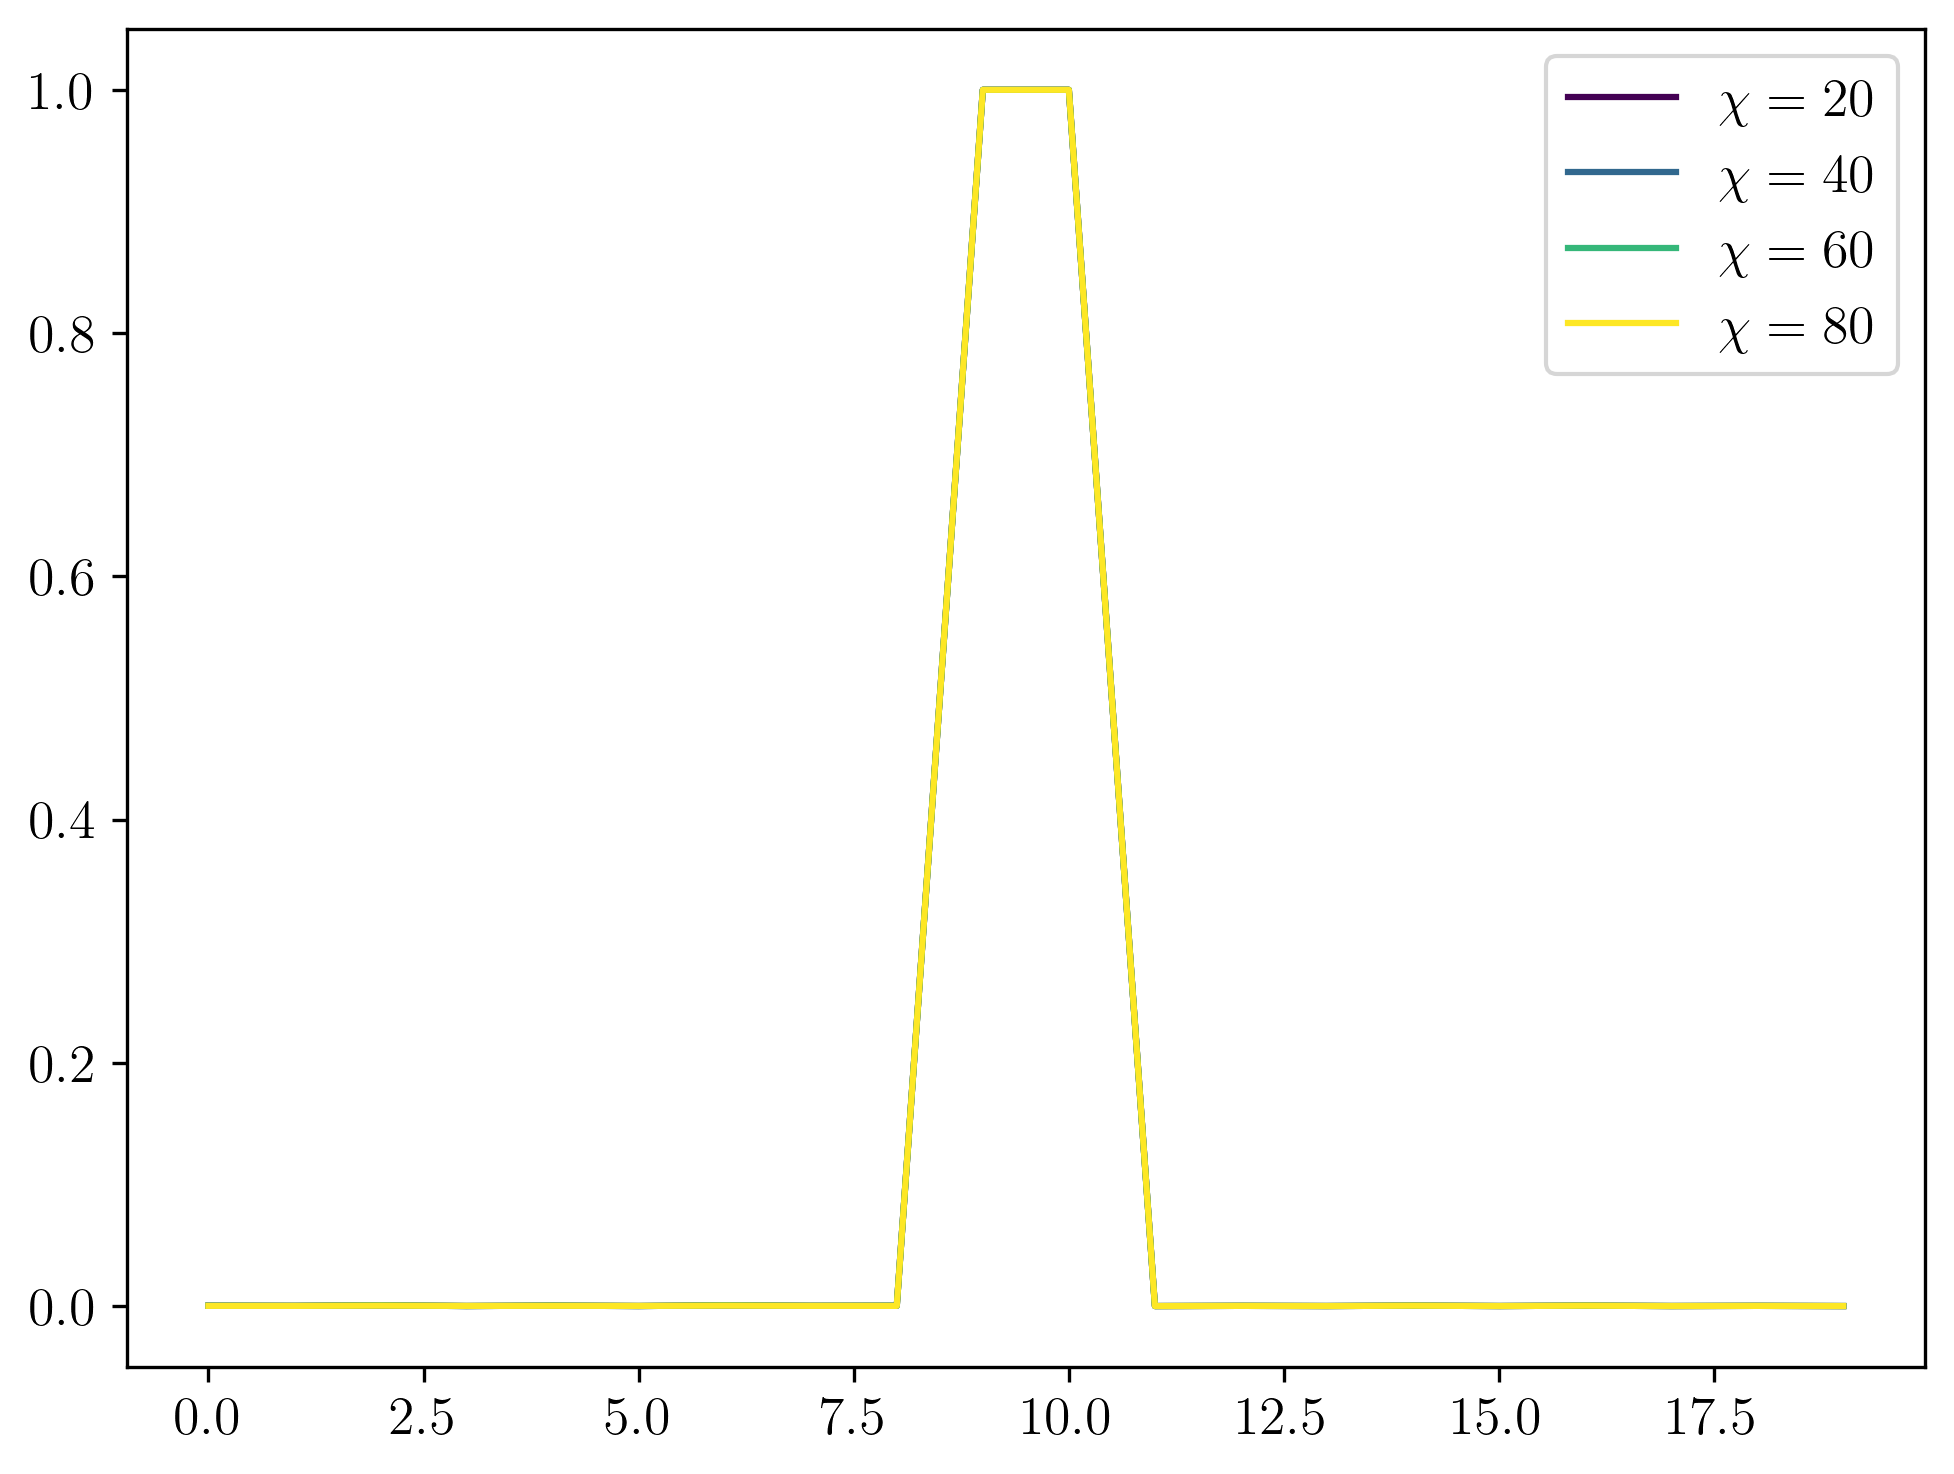

In [98]:
colors = create_sequential_colors(num_colors=len(chis))

for i, occup in enumerate(hole_occup):
    plt.plot(occup, color=colors[i], label=f"$\chi={chis[i]}$")
plt.legend()

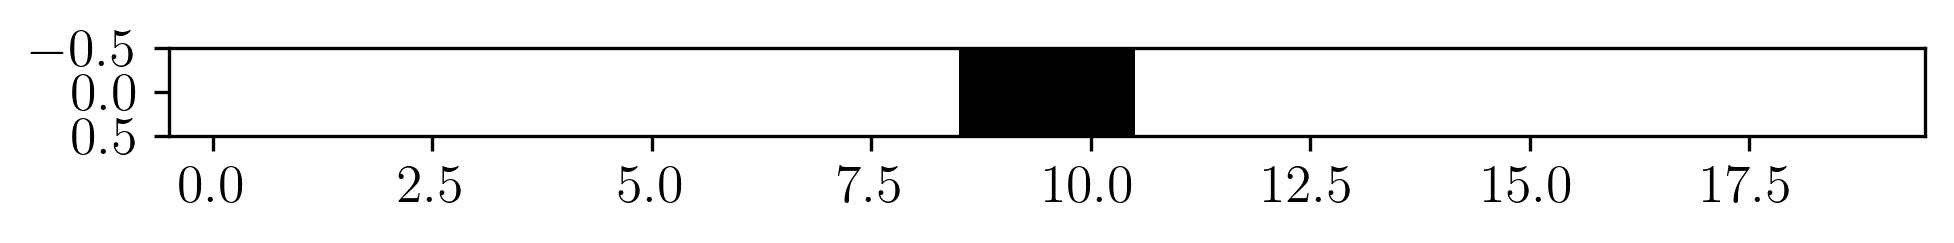

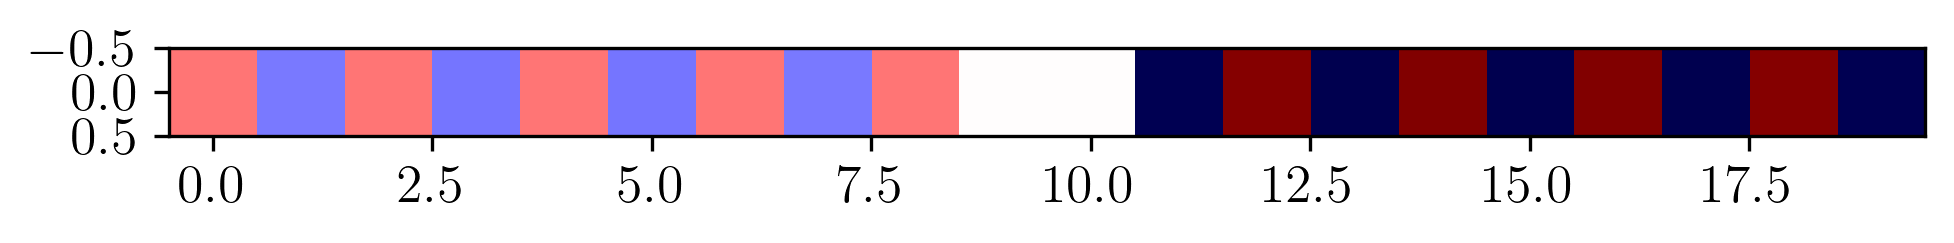

In [99]:
plt.imshow(np.asarray(hole_occup[-1]).reshape((1,L)), cmap="Greys", vmin=0, vmax=1)
plt.show()
plt.imshow(np.asarray(spin_occup[-1]).reshape((1,L)), cmap="seismic", vmin=-1, vmax=1)

In [100]:
spin_occup[-1]

[array(0.26582064),
 array(-0.26479579),
 array(0.26838835),
 array(-0.26884103),
 array(0.26861206),
 array(-0.26884147),
 array(0.26839027),
 array(-0.2647747),
 array(0.26578958),
 array(1.22057559e-24),
 array(2.287533e-26),
 array(-0.98005387),
 array(0.97498985),
 array(-0.98964554),
 array(0.98917565),
 array(-0.98993023),
 array(0.98917528),
 array(-0.98964503),
 array(0.97498258),
 array(-0.98005307)]